# **CA4 @ AI Spring 2025**
# Convolutional vs. Fully Connected Neural Networks

- **Name:** Majid Sadeghinejad
- **Student ID:** 810101459

---
Your submission should be named using the following format: `AI_CA4_LASTNAME_STUDENTID.ipynb`.

---

 *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says `WRITE YOUR ANSWER HERE` with your actual answer.
---
If you have any further questions or concerns, contact the TAs via email or Telegram.

# Introduction
In this assignment, you will compare fully connected neural networks with convolutional neural networks to evaluate whether convolutional architectures offer superior performance—and understand the reasons behind any observed differences.

**Important Note:**

Before you begin, please make sure to review the accompanying PyTorch tutorial provided alongside this file.

## Colab Setup

If you are running this notebook on Google Colab, you can mount your Google Drive using the following code to access or upload files directly from your Drive.

In [ ]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')

# GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', 'AIS25-CA4')
# os.chdir(GOOGLE_DRIVE_PATH)

In [13]:
import torch.optim as optim
import torch
from torchvision import transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import math
from torchsummary import summary
import matplotlib.pyplot as plt



## Device

As demonstrated in the PyTorch tutorial, PyTorch enable you to run your code on GPU to accelerate computations.

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Dataset

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [15]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [16]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.446), (0.247, 0.243, 0.261)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.446), (0.247, 0.243, 0.261)),
])

In [17]:
batch_size = 512

initial_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainset, valset = random_split(initial_trainset, [45000, 5000])

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
valloader   = DataLoader(valset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

**Why DataLoader vs Dataset?**

Dataset only knows how to index and return a single sample.
DataLoader wraps a Dataset to provide:
automatic batching
shuffling
parallel multi‐worker loading
optional pinning memory on CUDA devices
All of these are essential for efficient GPU training.

## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

In [18]:
# inverse the normilize transform to restore the original data
class UnNormalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean)[:,None,None]
        self.std  = torch.tensor(std)[:,None,None]

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be unnormalized.
        Returns:
            Tensor: Unnormalized image.
        """
        return tensor * self.std + self.mean

unnorm = UnNormalize(
    mean=(0.491, 0.482, 0.446),
    std =(0.247, 0.243, 0.261)
)

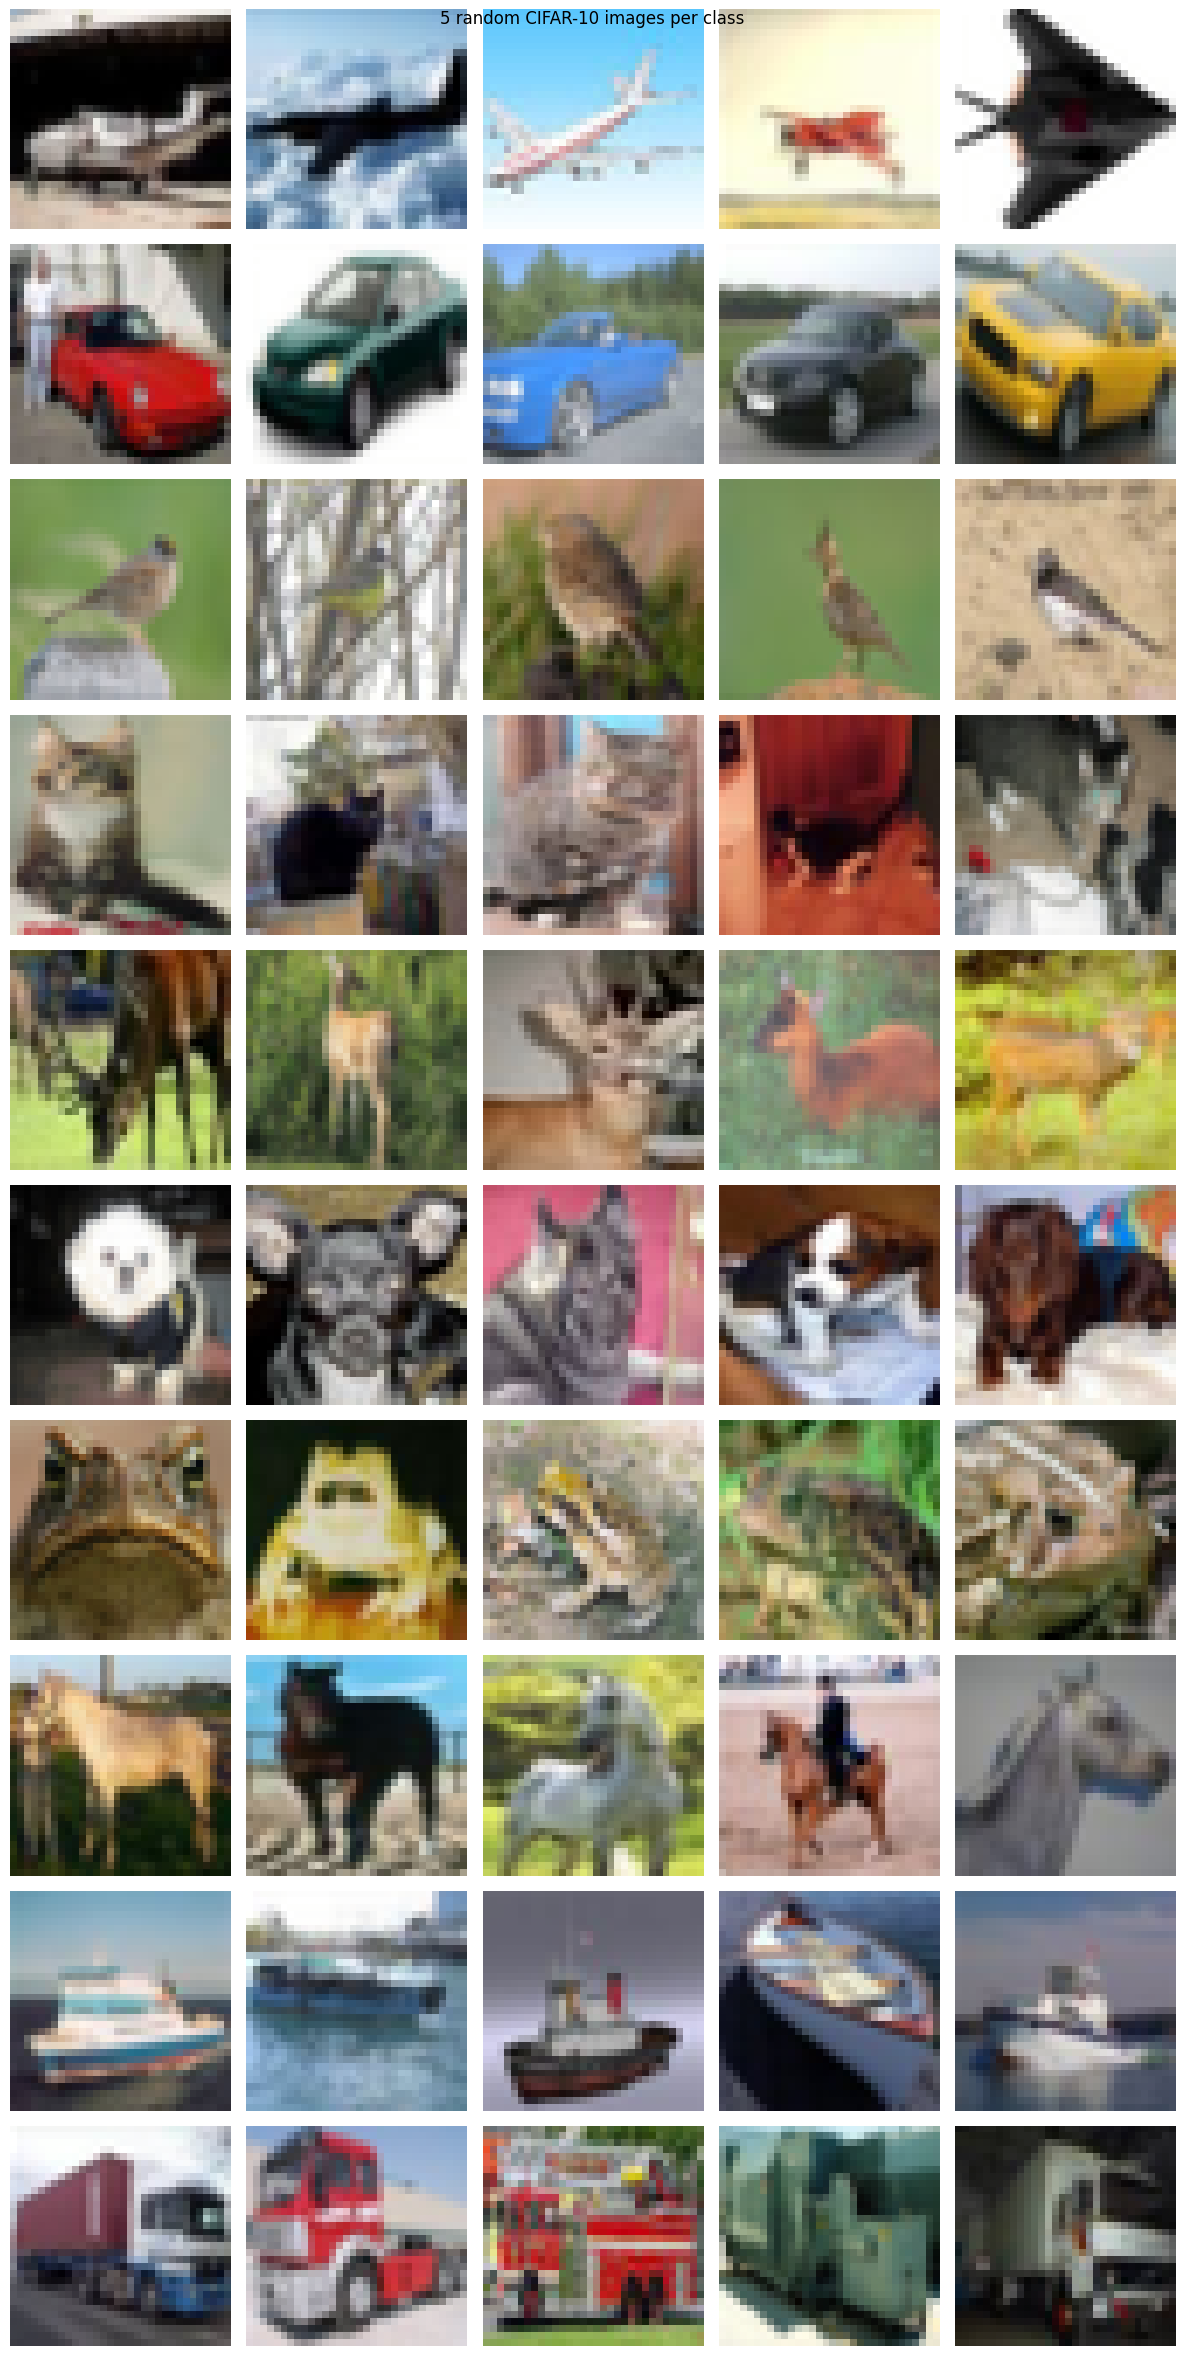

In [19]:
classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
dataset = initial_trainset

labels = np.array(dataset.targets)

fig, axes = plt.subplots(len(classes), 5, figsize=(12,24))
fig.suptitle("5 random CIFAR-10 images per class")

for cls_idx, cls_name in enumerate(classes):
    idxs = np.where(labels == cls_idx)[0]
    chosen = np.random.choice(idxs, 5, replace=False)
    for j, idx in enumerate(chosen):
        img, _ = dataset[idx]
        img = unnorm(img).permute(1,2,0).cpu().numpy().clip(0,1)
        ax = axes[cls_idx, j]
        ax.imshow(img)
        if j==0: ax.set_ylabel(cls_name, fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.show()

# Fully Connected Neural Netwrok

Your first task is to build a fully connected neural network with PyTorch. To achieve this, it is recommended that you familiarize yourself with the following PyTorch components and incorporate them into your network architecture:

* [`nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)
* [`nn.Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
* [`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
* [`nn.ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
* [`nn.Dropout`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
* [`nn.Flatten`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html)

In the provided template below, the final layer of the model should be defined separately and assigned the name `linear`, as it will be referenced in a later section of this assignment.

To ensure a fair comparison with convolutional neural networks (CNNs), both models should have approximately the same number of trainable parameters. Specifically, the fully connected model should contain **33,500,000 ± 500,000** trainable parameters.

You will calculate the exact number of trainable parameters in the following subsection to ensure this requirement is met.




In [20]:
class FullyConnectedNetwork(nn.Module):
    def __init__(self, input_shape=(3,32,32), num_classes=10, p_dropout=0.5):
        super().__init__()
        C,H,W = input_shape
        in_features = C*H*W

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 6144),
            nn.ReLU(inplace=True),
            nn.Dropout(p_dropout),

            nn.Linear(6144, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p_dropout),

            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p_dropout),
        )

        self.linear = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.net(x)
        return self.linear(x)

**How Dropout Works and Its Effects**

During training, each time we feed data forward: We randomly “drop” (turn off) a fraction *p* of the neurons by setting their outputs to zero.
During evaluation/testing: All neurons stay on, but we multiply their outputs by (1−p) so the overall scale matches training.

Effects:
- Stops neurons from relying too much on each other.
- Acts like training many smaller networks and averaging them .
- Reduces overfitting by forcing the network to learn more general, robust features.
- May slow down convergence slightly, but usually boosts final test accuracy.

## Trainable params

Based on the defined architecture, manually calculate the total number of trainable parameters:

Manual parameter count

L1 => (3072×6144) + 6144 => 18901760  
L2 => (6144×2048) + 2048 => 12584960  
L3 => (2048×1024) + 1024 => 2098176  
L4 => (1024×10) + 10 => 10250  
Total = 18901760 + 12584,960 + 2098176 + 10250  = 33595146  

Matches our target (around 33.5 M).

Once you have completed your hand calculation, you can verify your result by running the following cell:

In [21]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
summary(FullyConnectedNetwork().to(device), input_size=(3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                 [-1, 6144]      18,880,512
              ReLU-3                 [-1, 6144]               0
           Dropout-4                 [-1, 6144]               0
            Linear-5                 [-1, 2048]      12,584,960
              ReLU-6                 [-1, 2048]               0
           Dropout-7                 [-1, 2048]               0
            Linear-8                 [-1, 1024]       2,098,176
              ReLU-9                 [-1, 1024]               0
          Dropout-10                 [-1, 1024]               0
           Linear-11                   [-1, 10]          10,250
Total params: 33,573,898
Trainable params: 33,573,898
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Fo

## Train

### Model Instantiation

Create an instance of your model and move it to your selected device (CPU or GPU). Refer to the PyTorch-tutorial notebook for guidance on how to perform this operation.

In [22]:

model = FullyConnectedNetwork(p_dropout=0.5).to(device)

### Criterion & Optimizer


To train a neural network, we require a **loss function** (referred to as the *criterion*) to quantify the difference between the model's predictions and the true labels. This loss is then used to compute the gradients of the model parameters.

In addition, an **optimization algorithm** is needed to update the model's parameters using the calculated gradients, in order to minimize the loss over time.

You are encouraged to read about the following PyTorch components:

* [`nn.CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
* [`torch.optim.Adam`](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

In [23]:
epochs = 60
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-3,
    steps_per_epoch=len(trainloader),
    epochs=epochs
)

### Train loop

Train your model

Tasks:
- Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- save train/validation loss and accuracy (of each epoch) in an array for later usage

In [24]:
def train_epoch(net: torch.nn.Module, criterion: torch.nn.Module, optimizer: torch.optim.Optimizer ,dataloader: torch.utils.data.DataLoader):
    """
    Trains the neural network for a single epoch.

    Args:
        net (torch.nn.Module): The neural network model to be trained.
        criterion (torch.nn.Module): The loss function used to compute the training loss.
        optimizer (torch.optim.Optimizer): The optimization algorithm used to update model parameters.
        dataloader (torch.utils.data.DataLoader): DataLoader providing the training data in batches.

    Returns:
        tuple:
            - avg_loss (float): The average loss across all batches in the epoch.
            - accuracy (float): The classification accuracy (in percentage) over the entire dataset for the epoch.

    Notes:
        - The `criterion` computes the loss between the model's predictions and the true labels.
        - The `optimizer` updates the model's parameters based on the computed gradients to minimize the loss.
    """
    net.train()
    running_loss = 0.0
    correct = total = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = net(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)

    avg_loss = running_loss / total
    acc = 100. * correct / total
    return avg_loss, acc

def eval_epoch(net: torch.nn.Module, criterion: torch.nn.Module, dataloader: torch.utils.data.DataLoader, test_mode: bool = False):
    """
    Evaluates the neural network on a validation or test dataset for one epoch.
    """
    net.eval()
    running_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = net(X)
            loss = criterion(logits, y)

            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    avg_loss = running_loss / total
    acc = 100. * correct / total
    return avg_loss, acc

As previously mentioned, ensuring a fair comparison between models requires consistency in certain aspects of the training setup. One key factor is the number of **trainable parameters**, and another is the number of times the model processes the entire dataset—referred to as an **epoch**.

To maintain consistency in training duration across models, **do not modify** the `epochs` variable defined below.


In [12]:
epochs = 60 # Do not modify

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}


for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, criterion, optimizer, trainloader)
    val_loss, val_acc = eval_epoch(model, criterion, valloader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"(Epoch {epoch + 1} / {epochs}) train loss:{train_loss: .4f}; train acc:{train_acc: .2f}%; val loss:{val_loss: .4f}; val_acc:{val_acc: .2f}%")

(Epoch 1 / 60) train loss: 1.9361; train acc: 34.37%; val loss: 1.7719; val_acc: 42.84%
(Epoch 2 / 60) train loss: 1.7702; train acc: 42.82%; val loss: 1.6970; val_acc: 47.00%
(Epoch 3 / 60) train loss: 1.7046; train acc: 45.87%; val loss: 1.6644; val_acc: 47.72%
(Epoch 4 / 60) train loss: 1.6522; train acc: 48.24%; val loss: 1.6301; val_acc: 50.06%
(Epoch 5 / 60) train loss: 1.6217; train acc: 50.09%; val loss: 1.6128; val_acc: 50.58%
(Epoch 6 / 60) train loss: 1.5865; train acc: 51.82%; val loss: 1.5982; val_acc: 51.16%
(Epoch 7 / 60) train loss: 1.5641; train acc: 52.66%; val loss: 1.5835; val_acc: 52.02%
(Epoch 8 / 60) train loss: 1.5388; train acc: 53.77%; val loss: 1.5708; val_acc: 52.08%
(Epoch 9 / 60) train loss: 1.5156; train acc: 54.99%; val loss: 1.5615; val_acc: 53.08%
(Epoch 10 / 60) train loss: 1.4944; train acc: 56.17%; val loss: 1.5470; val_acc: 53.46%
(Epoch 11 / 60) train loss: 1.4749; train acc: 57.17%; val loss: 1.5457; val_acc: 54.12%
(Epoch 12 / 60) train loss: 1.

### Save Model

Save the trained model for use in subsequent sections to avoid retraining it later.


In [13]:
torch.save(model.state_dict(), "fully-connected.pth")

In [ ]:
# To load the previously saved model, simply uncomment the code below.
# model.load_state_dict(torch.load('fully-connected.pth'))

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

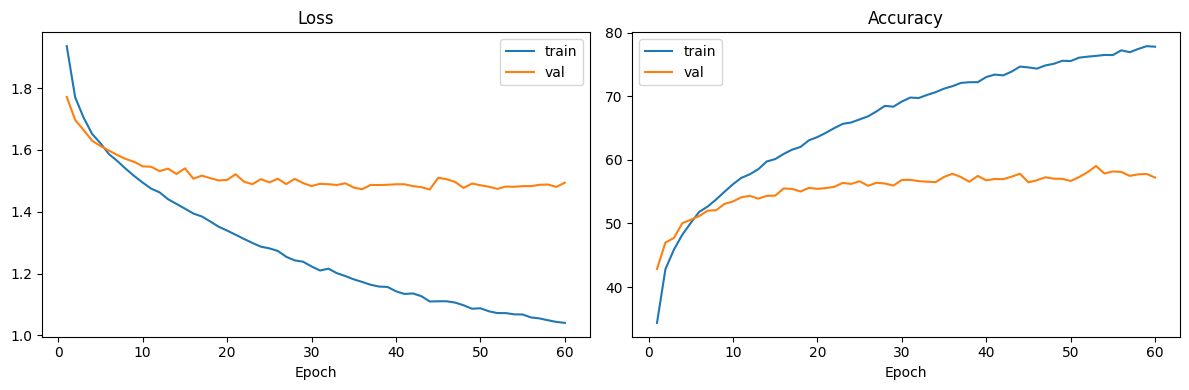

In [14]:
epochs_range = range(1, epochs+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, history['train_loss'], label='train')
plt.plot(epochs_range, history['val_loss'],   label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, history['train_acc'], label='train')
plt.plot(epochs_range, history['val_acc'],   label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `60%`

In [15]:
test_loss, test_acc = eval_epoch(model, criterion, testloader)
print(f"Test set -> loss: {test_loss:.4f}, accuracy: {test_acc:.2f}%")

Test set -> loss: 1.4819, accuracy: 57.89%


# Convolutional Neural Network

## Model

Define your model here from scratch (You are not allowed to use the existing models in pytorch)

**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (for each class). Define a "feature space" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). See the image below to get a better understanding. We will use this later (we want to access the feature space of a sample when the sample is given to the model). The model tries to learn a representation of the samples in this feature space and we will see how good it could do this in later sections.

![Feature Space In Neural Network](https://i.postimg.cc/28Qjcn9D/feature-space-vis.png)

 You are encouraged to learn about the following core components commonly used in convolutional neural networks:

* [`nn.Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
* [`nn.MaxPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

**Reminder**: The model you define should contain 33,500,000 ± 500,000 trainable parameters.

In [25]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, p_dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,    64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64,  128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.flatten = nn.Flatten()
        self.fc1     = nn.Sequential(
            nn.Linear(4096, 8192),
            nn.ReLU(inplace=True),
            nn.Dropout(p_dropout),
        )
        self.linear  = nn.Linear(8192, num_classes)

    def forward(self, x, return_features=False):
        x = self.features(x)
        x = self.flatten(x)
        feats = self.fc1(x)
        if return_features:
            return feats
        return self.linear(feats)


## Trainable params

Based on the defined architecture, manually calculate the total number of trainable parameters:

**Manual parameter count**

- Conv1 -> (3->64, 3×3) -> weights + biases = 3·3·3·64 + 64 = 1792  

- Conv2 -> (64→128, 3×3) -> weights + biases = 64·3·3·128 + 128  = 73856  

- Conv3 -> (128→256, 3×3) -> weights + biases = 128·3·3·256 + 256 = 295168  

Conv total = 1792 + 73856 + 295168 = 370816

- FC1 -> (4096→8192) -> weights + biases= 4096·8192 + 8192 = 33562624  

- Linear out -> (8192→10) -> weights + biases = 8192·10 + 10 = 81,930

Grand total = 370816 + 33562624 + 81930 = 34015370 (inside the range)  

Once you have completed your hand calculation, you can verify your result by running the following cell:

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
summary(CNN().to(device), input_size=(3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
         MaxPool2d-9            [-1, 256, 4, 4]               0
          Flatten-10                 [-1, 4096]               0
           Linear-11                 [-1, 8192]      33,562,624
             ReLU-12                 [-1, 8192]               0
          Dropout-13                 [-1, 8192]               0
           Linear-14                   

## Train

### Model instantiation

Create an instance of your model and move it to `device`

In [27]:
model = CNN(p_dropout=0.5).to(device)


### Criterion & Optimizer

Define `criterion` and `optimizer`

In [28]:
epochs = 60 # Do not modify
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=5e-3,
    steps_per_epoch=len(trainloader), epochs=epochs
)

### Train loop

Train your model

Tasks:
- Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- save train/validation loss and accuracy (of each epoch) in an array for later usage

In [29]:
epochs = 60 # Do not modify
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, criterion, optimizer, trainloader)
    val_loss, val_acc = eval_epoch(model, criterion, valloader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"(Epoch {epoch + 1} / {epochs}) train loss:{train_loss: .4f}; train acc:{train_acc: .2f}%; val loss:{val_loss: .4f}; val_acc:{val_acc: .2f}%")

(Epoch 1 / 60) train loss: 1.8083; train acc: 39.95%; val loss: 1.5754; val_acc: 50.78%
(Epoch 2 / 60) train loss: 1.5186; train acc: 54.20%; val loss: 1.4307; val_acc: 58.28%
(Epoch 3 / 60) train loss: 1.3990; train acc: 60.46%; val loss: 1.3415; val_acc: 63.46%
(Epoch 4 / 60) train loss: 1.3174; train acc: 64.77%; val loss: 1.2879; val_acc: 66.70%
(Epoch 5 / 60) train loss: 1.2606; train acc: 67.28%; val loss: 1.2508; val_acc: 67.42%
(Epoch 6 / 60) train loss: 1.2094; train acc: 69.96%; val loss: 1.2256; val_acc: 68.76%
(Epoch 7 / 60) train loss: 1.1750; train acc: 71.56%; val loss: 1.1846; val_acc: 70.66%
(Epoch 8 / 60) train loss: 1.1355; train acc: 73.63%; val loss: 1.1512; val_acc: 72.76%
(Epoch 9 / 60) train loss: 1.0978; train acc: 75.44%; val loss: 1.1337; val_acc: 73.12%
(Epoch 10 / 60) train loss: 1.0685; train acc: 76.92%; val loss: 1.1267; val_acc: 74.04%
(Epoch 11 / 60) train loss: 1.0369; train acc: 78.60%; val loss: 1.1178; val_acc: 75.00%
(Epoch 12 / 60) train loss: 1.

### Save Model

Since changes need to be made to the model later on, it is advisable to save your model to avoid having to retrain it in case of any issues.

In [30]:
torch.save(model.state_dict(), "cnn.pth")

In [ ]:
# To load the previously saved model, simply uncomment the code below.
# model.load_state_dict(torch.load('cnn.pth'))

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

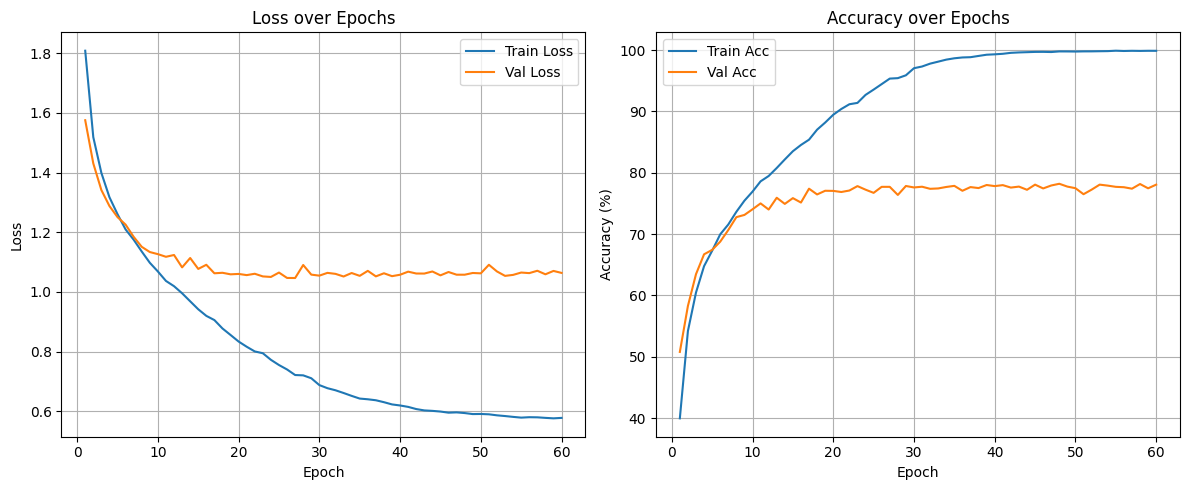

In [33]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'],   label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc')
plt.plot(epochs_range, history['val_acc'],   label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `80%`

In [34]:
test_loss_c, test_acc_c = eval_epoch(model, criterion, testloader)
print(f"CNN Test -> loss: {test_loss_c:.4f}, acc: {test_acc_c:.2f}%")

CNN Test -> loss: 1.0776, acc: 76.83%


## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model. Note that if you used normalization in the transform function for loading the data, you will need to unnormalize the images before displaying them.

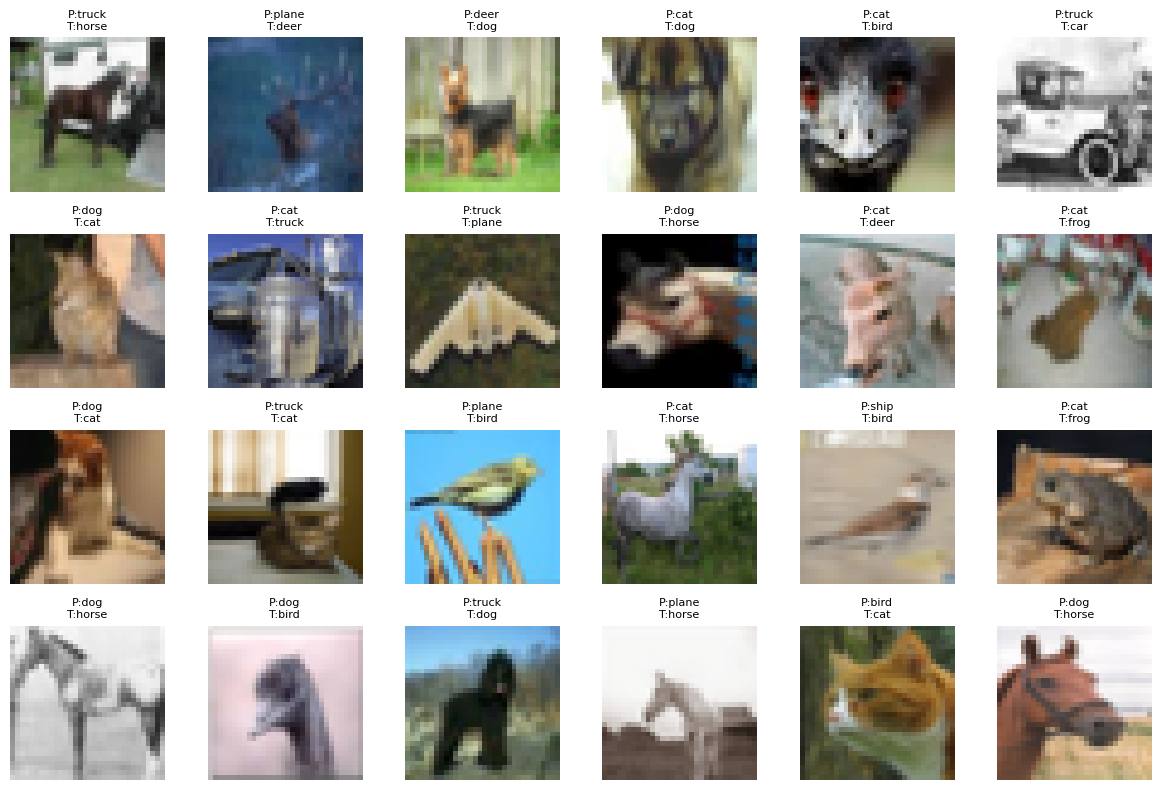

In [35]:
import matplotlib.pyplot as plt

mis_imgs, mis_preds, mis_labels = [], [], []
for X,y in testloader:
    X,y = X.to(device), y.to(device)
    logits = model(X)
    preds = logits.argmax(1)
    mask = preds != y
    mis_imgs.append(X[mask])
    mis_preds.append(preds[mask])
    mis_labels.append(y[mask])
mis_imgs   = torch.cat(mis_imgs)[:24]
mis_preds  = torch.cat(mis_preds)[:24]
mis_labels = torch.cat(mis_labels)[:24]

plt.figure(figsize=(12,8))
for i in range(24):
    plt.subplot(4,6,i+1)
    img = unnorm(mis_imgs[i].cpu()).permute(1,2,0).numpy().clip(0,1)
    plt.imshow(img)
    plt.title(f"P:{classes[mis_preds[i]]}\nT:{classes[mis_labels[i]]}", fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Exploring the feature space

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate it's "feature space" discussed in the model section. The result of this section should be a tensor of size `(45000, N)` saved in a variable (for later usage)

- **Hint:** Pay attension to the `shuffle` attribute of your train dataloader (If needed)

In [36]:
from torch.utils.data import DataLoader

feature_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

model.eval()
feature_list = []
with torch.no_grad():
    for X, _ in feature_loader:
        feats = model(X.to(device), return_features=True)
        feature_list.append(feats.cpu())

feature_space = torch.cat(feature_list, dim=0)
print("Feature space shape:", feature_space.shape)

Feature space shape: torch.Size([45000, 8192])


### K Nearest Neighbor in feature space

We already have calculated the feature spaces for trainset ($S$) in the previous section. Now we follow these steps to explore the featre space:

1. Get 5 random samples from testset which are correctly predicted by the model.
2. for each sample, calculate it's "feature space" ($X$)
3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them

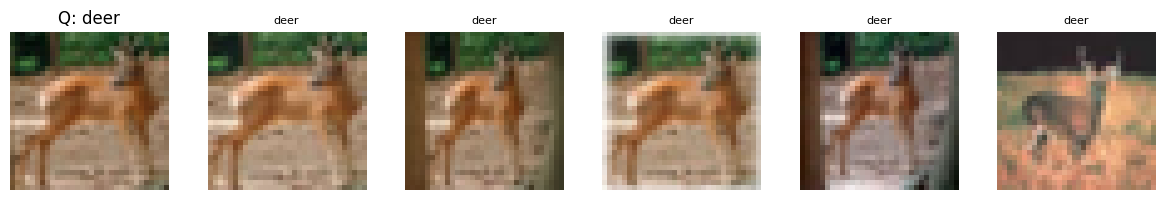

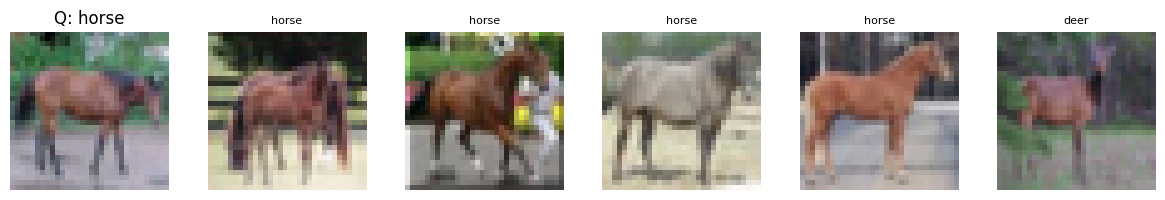

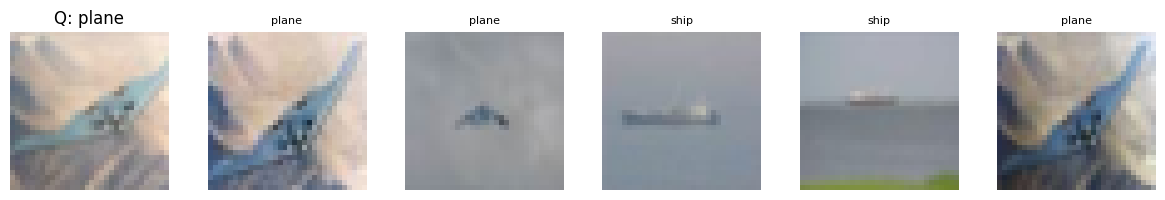

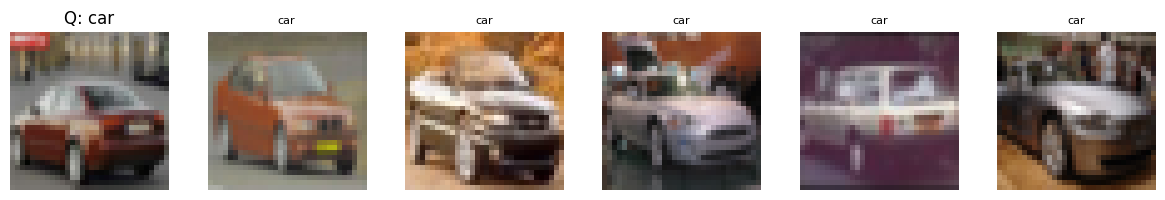

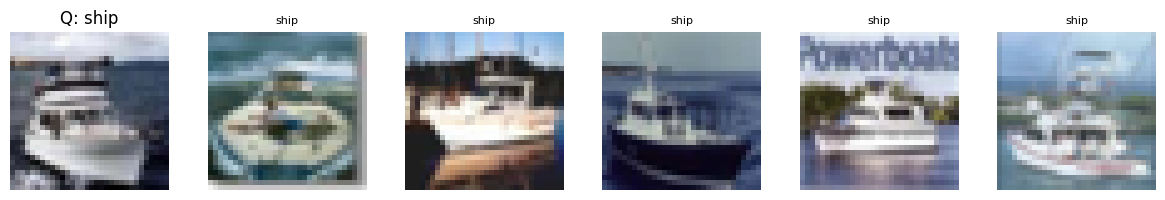

In [37]:
model.eval()
correct_feats = []
correct_imgs  = []
correct_lbls  = []
with torch.no_grad():
    for X, y in testloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        preds = logits.argmax(1)
        mask  = preds == y
        if mask.any():
            feats = model(X, return_features=True)[mask].cpu()
            correct_feats.append(feats)
            correct_imgs.append(X[mask].cpu())
            correct_lbls.append(y[mask].cpu())

correct_feats = torch.cat(correct_feats)
correct_imgs  = torch.cat(correct_imgs)
correct_lbls  = torch.cat(correct_lbls)
perm = torch.randperm(len(correct_feats))[:5]
sel_feats = correct_feats[perm]
sel_imgs  = correct_imgs[perm]
sel_lbls  = correct_lbls[perm]


import matplotlib.pyplot as plt

for i in range(5):
    q_feat = sel_feats[i].unsqueeze(0)
    dists = torch.cdist(q_feat, feature_space).squeeze(0)
    knn_idx = torch.topk(dists, k=5, largest=False).indices

    fig, axs = plt.subplots(1, 6, figsize=(12,2))
    q_img = unnorm(sel_imgs[i]).permute(1,2,0).numpy().clip(0,1)
    axs[0].imshow(q_img)
    axs[0].set_title(f"Q: {classes[sel_lbls[i]]}")
    axs[0].axis('off')

    for j, idx in enumerate(knn_idx):
        img, lbl = trainset[idx]
        img = unnorm(img).permute(1,2,0).numpy().clip(0,1)
        axs[j+1].imshow(img)
        axs[j+1].set_title(classes[lbl], fontsize=8)
        axs[j+1].axis('off')

    plt.tight_layout()
    plt.show()

### TSNE

Let's follow these steps to explore feature space even more:

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)
2. Now we have a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now we have a vector of size `(M, 2)`)
4. Visualize the points in a 2D plane (Set color of each point based on it's class)


In [38]:
from sklearn.manifold import TSNE

indices = np.random.randint(0, len(feature_space), 2000)
feature_space = feature_space[indices]
tsne = TSNE(n_components=2, random_state=42)
reduced_space = tsne.fit_transform(feature_space.reshape(feature_space.shape[0], -1).detach().cpu().numpy())

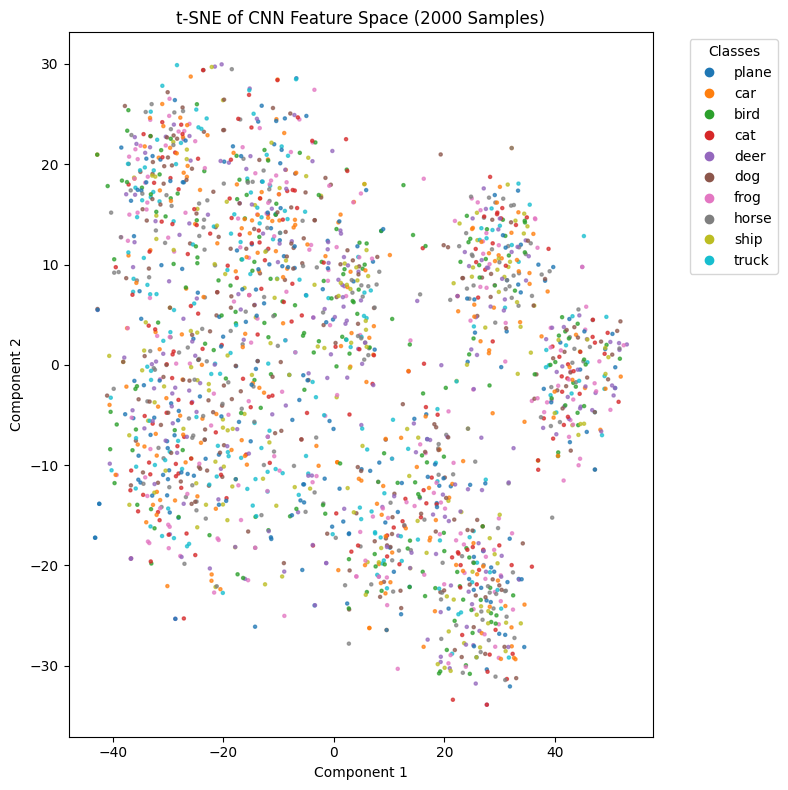

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

all_targets  = np.array(initial_trainset.targets)
train_labels = all_targets[trainset.indices]

M = 2000
idx = np.random.choice(feature_space.shape[0], M, replace=False)
feats_subset  = feature_space[idx].cpu().numpy()
labels_subset = train_labels[idx]

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(feats_subset)

plt.figure(figsize=(8,8))
scatter = plt.scatter(
    reduced[:,0], reduced[:,1],
    c=labels_subset, cmap='tab10', s=5, alpha=0.7)

handles = [
    Line2D([0],[0], marker='o', color=plt.cm.tab10(i/10), linestyle='', markersize=6) for i in range(10)
]

plt.legend(handles, classes, title='Classes', bbox_to_anchor=(1.05,1), loc='upper left')

plt.title("t-SNE of CNN Feature Space (2000 Samples)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

### Feature Map


In this part, we are going to visualize the output of one of the convolutional layers to see what features they focus on.

First, let's select a random image from dataset.

In [43]:
image = trainset[3][0]

Now, we are going to *clip* our model at different points to get different intermediate representation.
* Clip your model at least at one point and plot the filters output. You can use the output of first Resnet block.

In order to clip the model, you can use `model.children()` method. For example, to get output only after the first 2 layers, you can do:

```
clipped = nn.Sequential(
    *list(model.children()[:2])
)
intermediate_output = clipped(input)
```



In [44]:
import torch.nn as nn
import math

image = trainset[3][0]

x = image.unsqueeze(0).to(device)

clipped = nn.Sequential(*list(model.features.children())[:2])

intermediate_output = clipped(x)

print("Intermediate output shape:", intermediate_output.shape)

Intermediate output shape: torch.Size([1, 64, 32, 32])


In [45]:
intermediate_output.shape

torch.Size([1, 64, 32, 32])

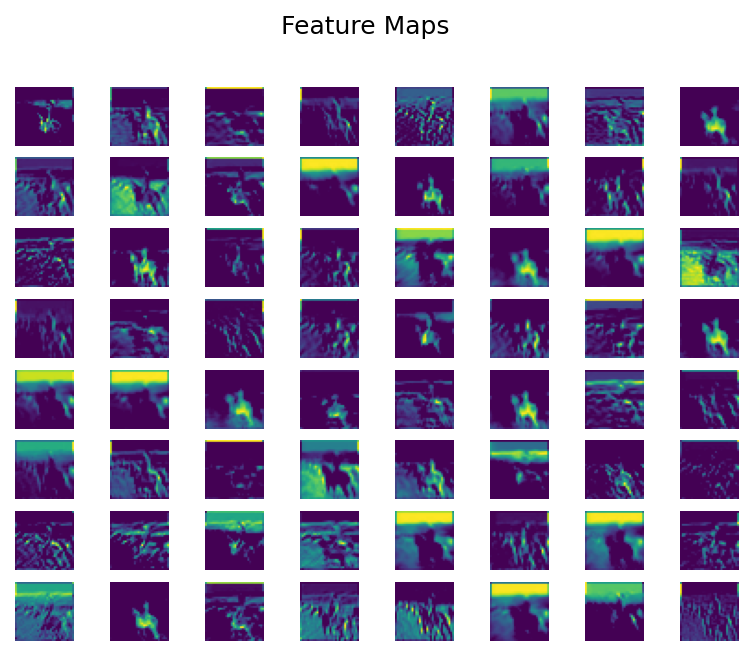

In [46]:
import matplotlib.pyplot as plt

def plot_intermediate_output(result, title=None):
    """
    Plots the intermediate output of shape
    N_FILTERS x H x W
    """
    plt.rcParams['figure.dpi'] = 150
    n_filters = result.shape[1]
    N = int(math.sqrt(n_filters))
    M = (n_filters + N - 1) // N
    assert N * M >= n_filters

    fig, axs = plt.subplots(N, M)
    fig.suptitle(title)

    for i in range(N):
        for j in range(M):
            if i*N + j < n_filters:
                axs[i][j].imshow(result[0, i*N + j].cpu().detach())
                axs[i][j].axis('off')

plot_intermediate_output(intermediate_output, title='Feature Maps')


**Note:** You are expected to analyze all results presented in this notebook and thoughtfully consider the underlying reasons behind them. Be prepared to discuss your insights during the **in-person review session**.
A written report is not required.
